# Fake News Detection — Nível 1: Modelos Lineares com TF-IDF

---

## Contexto do Problema

A proliferação de **fake news** em plataformas digitais é um dos grandes desafios da sociedade da informação. Segundo o Reuters Institute Digital News Report (2023), mais de 56% dos internautas globais relatam dificuldade em distinguir notícias reais de fabricadas.

Do ponto de vista de **Processamento de Linguagem Natural (NLP)**, a detecção automática de fake news é formulada como um problema de **classificação binária supervisionada de texto**:

> Dado o título e o corpo de um artigo jornalístico, predizer se ele é **real** (1) ou **falso** (0).

---

## Dataset

O dataset utilizado é o **Kaggle Fake and Real News Dataset**:

| Atributo | Detalhe |
|----------|---------|
| **Artigos falsos** | 23.481 |
| **Artigos reais** | 21.417 |
| **Total** | 44.898 artigos |
| **Features** | `title`, `text`, `subject`, `date` |
| **Período** | 2015–2017 (eleição americana, era Trump) |
| **Fonte dos reais** | Reuters News Agency |
| **Fonte dos falsos** | Sites de fake news catalogados |

---

## Objetivo deste Notebook

Este é o **Nível 1** de uma pipeline progressiva de detecção de fake news. Implementamos os **modelos baseline clássicos** de NLP:

1. **TF-IDF** como representação vetorial esparsa do texto
2. **Regressão Logística** com regularização L2 — modelo probabilístico
3. **Support Vector Machine Linear** (`LinearSVC`) — modelo de máxima margem

> **Por que começar aqui?** Modelos lineares sobre TF-IDF são surpreendentemente competitivos em classificação de texto, treinam em segundos e têm coeficientes interpretáveis. Qualquer modelo mais complexo (LSTM, BERT) precisa superar este baseline para justificar seu custo adicional.

---

## Estrutura do Notebook

| # | Seção | Conteúdo |
|---|-------|----------|
| 1 | Setup | Imports e configurações globais |
| 2 | Dados | Carregamento e análise exploratória |
| 3 | ⚠️ Leakage | Análise crítica de vazamentos de dados |
| 4 | Pré-processamento | Pipeline de limpeza e normalização |
| 5 | TF-IDF | Teoria matemática e vetorização |
| 6 | Regressão Logística | Teoria, treino, validação cruzada e avaliação |
| 7 | LinearSVC | Teoria, treino, validação cruzada e avaliação |
| 8 | Comparação | Análise side-by-side dos dois modelos |
| 9 | Interpretabilidade | Palavras mais discriminativas por classe |
| 10 | Leakage Δ | Impacto quantificado do data leakage |
| 11 | Conclusões | Resumo, limitações e próximos passos |

## 1. Configuração do Ambiente

Importamos todas as dependências no início do notebook para facilitar a reprodutibilidade. Fixamos a semente aleatória `RANDOM_STATE = 42` para garantir resultados idênticos em qualquer execução.

In [1]:
# ── Bibliotecas padrão ──────────────────────────────────────────────────────
import os
import re
import time
import warnings
warnings.filterwarnings('ignore')

# ── Dados ────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualização ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── NLP ──────────────────────────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords

# ── Machine Learning ─────────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    f1_score, accuracy_score, precision_score, recall_score
)

# ── Downloads NLTK ────────────────────────────────────────────────────────────
nltk.download('stopwords', quiet=True)

# ── Configurações globais ─────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Paleta de cores consistente ao longo do notebook
PALETTE = {
    'fake':    '#E74C3C',   # vermelho  — classe 0 (Fake)
    'real':    '#2ECC71',   # verde     — classe 1 (Real)
    'neutral': '#3498DB',   # azul      — uso geral
}

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.labelsize': 11})
sns.set_style('whitegrid')

print('Ambiente configurado.')
print(f'  NumPy        : {np.__version__}')
print(f'  Pandas       : {pd.__version__}')
print(f'  Scikit-learn : {__import__("sklearn").__version__}')

Ambiente configurado.
  NumPy        : 2.4.6
  Pandas       : 3.0.3
  Scikit-learn : 1.9.0


[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1081)>


## 2. Carregamento dos Dados

### Estrutura dos Arquivos

O dataset é distribuído em dois CSVs separados por classe:

- `Fake.csv` → notícias fabricadas → **label = 0**
- `True.csv` → notícias verificadas (Reuters) → **label = 1**

Após carregar ambos, concatenamos e **embaralhamos** o dataset completo. O embaralhamento é importante para evitar que qualquer viés de ordem dos dados afete a divisão treino/teste ou a validação cruzada.

In [2]:
DATA_DIR = '../data'

# Carrega os dois CSVs e atribui labels binários
df_fake = pd.read_csv(os.path.join(DATA_DIR, 'Fake.csv'))
df_real = pd.read_csv(os.path.join(DATA_DIR, 'True.csv'))

df_fake['label'] = 0   # Fake = 0
df_real['label'] = 1   # Real = 1

# Concatena e embaralha (reset_index para índice limpo)
df = (pd.concat([df_fake, df_real], ignore_index=True)
        .sample(frac=1, random_state=RANDOM_STATE)
        .reset_index(drop=True))

print(f'Total de artigos : {len(df):,}')
print(f'Colunas          : {df.columns.tolist()}')
print(f'\nValores nulos:')
print(df.isnull().sum().to_string())
df.head(3)

Total de artigos : 44,898
Colunas          : ['title', 'text', 'subject', 'date', 'label']

Valores nulos:
title      0
text       0
subject    0
date       0
label      0


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1


### 2.1 Análise Exploratória dos Dados (EDA)

Antes de modelar, precisamos entender a distribuição do dataset:

- **Balanceamento de classes**: classes muito desbalanceadas exigem ajuste de pesos ou métricas específicas (F1 vs. Accuracy)
- **Comprimento dos textos**: artigos muito curtos podem não ter informação suficiente
- **Categorias (`subject`)**: podem revelar vazamentos de dados — investigaremos na próxima seção

In [3]:
# ── Distribuição de classes ───────────────────────────────────────────────────
counts = df['label'].value_counts()
pct    = df['label'].value_counts(normalize=True) * 100

print('=== Distribuição de Classes ===')
print(f'  Fake (0) : {counts[0]:,} artigos  ({pct[0]:.1f}%)')
print(f'  Real (1) : {counts[1]:,} artigos  ({pct[1]:.1f}%)')

# ── Features de comprimento ───────────────────────────────────────────────────
df['word_count'] = df['text'].astype(str).str.split().str.len()
df['text_len']   = df['text'].astype(str).str.len()
df['title_len']  = df['title'].astype(str).str.len()

print('\n=== Estatísticas de Comprimento do Texto (palavras) ===')
stats = (df.groupby('label')['word_count']
           .describe()
           .round(1)
           .rename(index={0: 'Fake', 1: 'Real'}))
print(stats.to_string())

# ── Categorias por classe ─────────────────────────────────────────────────────
print('\n=== Categorias — Fake ===')
print(df_fake['subject'].value_counts().to_string())
print('\n=== Categorias — Real ===')
print(df_real['subject'].value_counts().to_string())

=== Distribuição de Classes ===
  Fake (0) : 23,481 artigos  (52.3%)
  Real (1) : 21,417 artigos  (47.7%)



=== Estatísticas de Comprimento do Texto (palavras) ===
         count   mean    std  min    25%    50%    75%     max
label                                                         
Fake   23481.0  423.2  408.4  0.0  240.0  363.0  506.0  8135.0
Real   21417.0  385.6  274.0  0.0  148.0  359.0  525.0  5172.0

=== Categorias — Fake ===
subject
News               9050
politics           6841
left-news          4459
Government News    1570
US_News             783
Middle-east         778

=== Categorias — Real ===
subject
politicsNews    11272
worldnews       10145


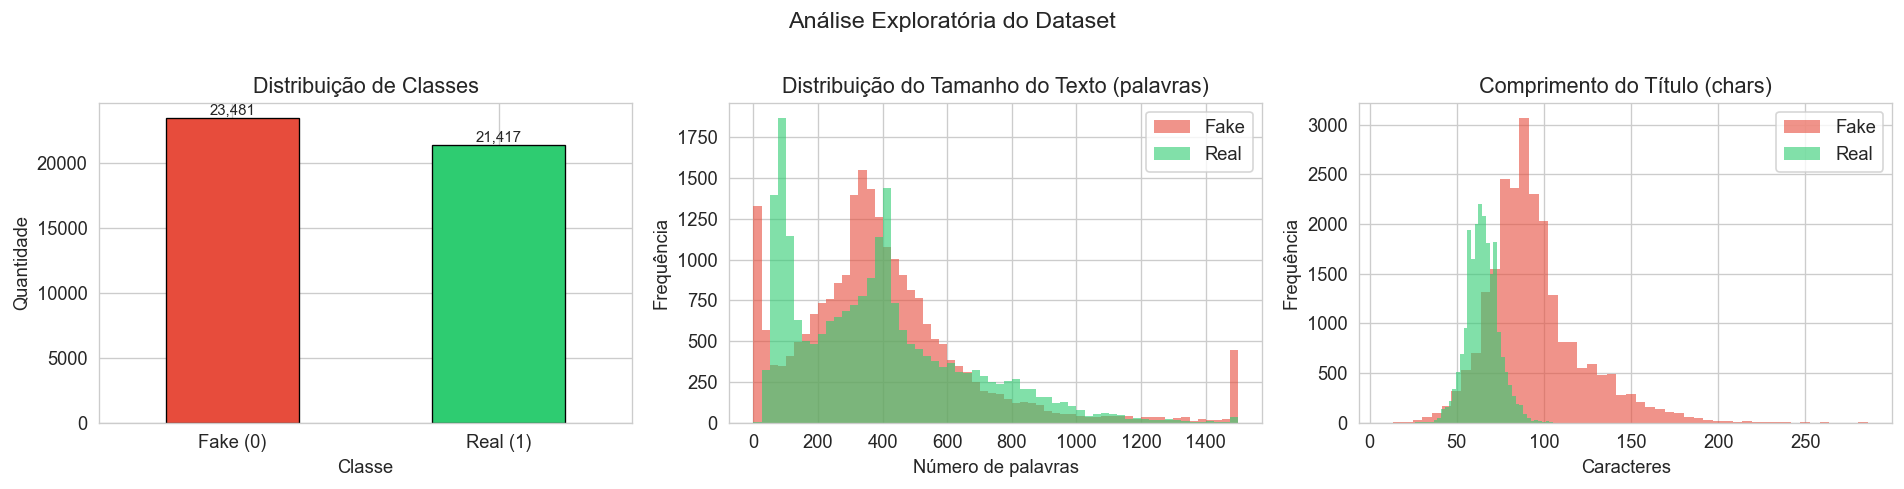

In [4]:
# ── Visualizações de EDA ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Distribuição de classes
bar_colors = [PALETTE['fake'], PALETTE['real']]
counts.plot(kind='bar', ax=axes[0], color=bar_colors, edgecolor='black', lw=0.8)
axes[0].set_title('Distribuição de Classes')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Quantidade')
axes[0].set_xticklabels(['Fake (0)', 'Real (1)'], rotation=0)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 200,
                 f'{bar.get_height():,.0f}', ha='center', fontsize=9)

# 2. Distribuição de contagem de palavras (clamp em 1.500 para legibilidade)
for label, color, name in [(0, PALETTE['fake'], 'Fake'), (1, PALETTE['real'], 'Real')]:
    vals = df[df['label'] == label]['word_count'].clip(upper=1500)
    axes[1].hist(vals, bins=60, alpha=0.6, color=color, label=name, edgecolor='none')
axes[1].set_title('Distribuição do Tamanho do Texto (palavras)')
axes[1].set_xlabel('Número de palavras')
axes[1].set_ylabel('Frequência')
axes[1].legend()

# 3. Distribuição do comprimento do título
for label, color, name in [(0, PALETTE['fake'], 'Fake'), (1, PALETTE['real'], 'Real')]:
    vals = df[df['label'] == label]['title_len']
    axes[2].hist(vals, bins=50, alpha=0.6, color=color, label=name, edgecolor='none')
axes[2].set_title('Comprimento do Título (chars)')
axes[2].set_xlabel('Caracteres')
axes[2].set_ylabel('Frequência')
axes[2].legend()

plt.suptitle('Análise Exploratória do Dataset', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 3. ⚠️ Análise Crítica de Data Leakage

> **Data Leakage** (vazamento de dados) ocorre quando informações que não estariam disponíveis em produção "vazam" para o processo de treinamento, inflando artificialmente as métricas de avaliação. O modelo aprende atalhos espúrios em vez do padrão real do problema.

### Dois Vazamentos Identificados

#### Vazamento 1 — Byline Reuters no Corpo do Texto

**99,82%** dos artigos reais começam com o padrão `"CIDADE (Reuters) - "`. Qualquer modelo bag-of-words aprende imediatamente:

```
"reuters" → Real
```

Isso é completamente inútil em produção, pois notícias falsas simplesmente não incluiriam essa byline.

#### Vazamento 2 — Coluna `subject`

As categorias são **totalmente distintas** entre as classes:

| Fake | Real |
|------|------|
| `News`, `politics`, `left-news`, `Government News` | `politicsNews`, `worldnews` |

Um classificador ingênuo baseado apenas no `subject` alcançaria ~100% de acurácia. Isso não representa habilidade de detectar fake news — representa memorização de metadados.

### Decisão de Tratamento

Para uma avaliação **honesta e generalizável**, adotamos:

1. **Remover** `subject` e `date` das features (apenas `title` + `text`)
2. **Remover** a byline Reuters via regex no pré-processamento
3. **Comparar** os dois cenários ao final do notebook para quantificar o impacto

In [5]:
# ── Evidenciando Leakage 1: byline Reuters ───────────────────────────────────
reuters_real = df[df['label'] == 1]['text'].str.contains('Reuters', case=False, na=False).mean()
reuters_fake = df[df['label'] == 0]['text'].str.contains('Reuters', case=False, na=False).mean()

print('=== Leakage 1: Byline Reuters ===')
print(f'  Presente em artigos Reais : {reuters_real:.2%}')
print(f'  Presente em artigos Fakes : {reuters_fake:.2%}')

# Exemplo do padrão que precisa ser removido
sample = df[df['label'] == 1]['text'].iloc[0][:130]
print(f'\n  Exemplo de início de artigo real:')
print(f'  "{sample}..."')

# ── Evidenciando Leakage 2: coluna subject ────────────────────────────────────
print('\n=== Leakage 2: Distribuição da Coluna subject por Classe ===')
crosstab = pd.crosstab(df['subject'], df['label']).rename(columns={0: 'Fake', 1: 'Real'})
print(crosstab.to_string())
print('\n→ As categorias são mutuamente exclusivas: trivialmente classificável pelo subject.')

=== Leakage 1: Byline Reuters ===
  Presente em artigos Reais : 99.82%
  Presente em artigos Fakes : 1.37%

  Exemplo de início de artigo real:
  "WASHINGTON (Reuters) - U.S. President Donald Trump removed his chief strategist Steve Bannon from the National Security Council on..."

=== Leakage 2: Distribuição da Coluna subject por Classe ===
label            Fake   Real
subject                     
Government News  1570      0
Middle-east       778      0
News             9050      0
US_News           783      0
left-news        4459      0
politics         6841      0
politicsNews        0  11272
worldnews           0  10145

→ As categorias são mutuamente exclusivas: trivialmente classificável pelo subject.


## 4. Pré-processamento de Texto

### Por Que Pré-processar?

Modelos de ML operam sobre vetores numéricos. O pré-processamento de texto tem três objetivos principais:

1. **Reduzir o espaço vocabular** — "News", "news" e "NEWS" são o mesmo token; sem normalização ocupam três entradas distintas na matriz TF-IDF
2. **Remover ruído** — URLs, artefatos HTML, pontuação excessiva não carregam informação semântica relevante para classificação
3. **Eliminar atalhos espúrios** — byline Reuters (data leakage)

### Pipeline de Limpeza

```
Texto bruto
    │
    ├─ 1. Lowercase normalization
    │      "Trump SAYS..." → "trump says..."
    │
    ├─ 2. Remoção da byline Reuters
    │      "WASHINGTON (Reuters) - ..." → "..."
    │
    ├─ 3. Remoção de URLs
    │      "https://t.co/xyz abc" → "abc"
    │
    ├─ 4. Remoção de caracteres não-alfanuméricos
    │      "trump's tweet!" → "trump s tweet"
    │
    ├─ 5. Remoção de stopwords e tokens curtos
    │      ["trump", "s", "tweet"] → ["trump", "tweet"]
    │      (remove artigos, preposições, pronomes)
    │
    └─ Texto limpo ✓
```

### Nota sobre Stemming/Lemmatização

Não aplicamos stemming ou lemmatização neste nível. O TF-IDF com palavras inteiras já produz excelentes resultados para classificação, e preservar as formas originais facilita a interpretação dos coeficientes na seção de *features discriminativas*.

In [6]:
# ── Carrega stopwords em inglês ───────────────────────────────────────────────
STOP_WORDS = set(stopwords.words('english'))

# Padrão da byline Reuters: "WASHINGTON (Reuters) - " ou "NEW YORK, Jan 1 (Reuters) -"
# Captura: texto em maiúsculas + possível vírgula/ponto/espaço + "(Reuters)" + separador
REUTERS_RE = re.compile(
    r'^[A-Z][A-Z\s,\.]{2,40}\(Reuters\)\s*[-\u2013]\s*',
    re.IGNORECASE
)

def preprocess(text):
    # Garante que a entrada é string
    if not isinstance(text, str):
        return ''

    # 1. Lowercase
    text = text.lower()

    # 2. Remove byline Reuters
    text = REUTERS_RE.sub('', text)

    # 3. Remove URLs (http, https, www)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # 4. Remove caracteres não-alfanuméricos (mantém espaços)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)

    # 5. Tokeniza, remove stopwords e tokens com <= 1 caractere
    tokens = [t for t in text.split() if t not in STOP_WORDS and len(t) > 1]

    return ' '.join(tokens)


# ── Aplica a pipeline ─────────────────────────────────────────────────────────
print('Aplicando pré-processamento...')
t0 = time.time()

df['title_clean'] = df['title'].apply(preprocess)
df['text_clean']  = df['text'].apply(preprocess)

# Concatena título + texto com marcador especial de fronteira
# O separador TITLEEND permite que o modelo diferencie padrões do título vs. corpo
df['full_text'] = df['title_clean'] + ' titleend ' + df['text_clean']

elapsed = time.time() - t0
print(f'Concluído em {elapsed:.1f}s')

# ── Exemplos antes e depois ───────────────────────────────────────────────────
idx_real = df[df['label'] == 1].index[0]
idx_fake = df[df['label'] == 0].index[0]

print('\n=== Artigo REAL — antes/depois ===')
print(f'  Antes : {df.loc[idx_real, "text"][:120]}...')
print(f'  Depois: {df.loc[idx_real, "text_clean"][:120]}...')

print('\n=== Artigo FAKE — antes/depois ===')
print(f'  Antes : {df.loc[idx_fake, "text"][:120]}...')
print(f'  Depois: {df.loc[idx_fake, "text_clean"][:120]}...')

Aplicando pré-processamento...


Concluído em 7.3s

=== Artigo REAL — antes/depois ===
  Antes : WASHINGTON (Reuters) - U.S. President Donald Trump removed his chief strategist Steve Bannon from the National Security ...
  Depois: president donald trump removed chief strategist steve bannon national security council wednesday reversing controversial...

=== Artigo FAKE — antes/depois ===
  Antes : 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing...
  Depois: 21st century wire says ben stein reputable professor pepperdine university also hollywood fame appearing tv shows films ...


## 5. Representação Vetorial — TF-IDF

### Limitações do Bag of Words Simples

A abordagem mais ingênua é o **Bag of Words (BoW)**: contar a frequência absoluta de cada palavra no documento. O problema: palavras muito frequentes em todo o corpus (como *"said"*, *"president"*, *"year"*) dominam o espaço vetorial sem carregar poder discriminativo entre classes.

### Term Frequency — Inverse Document Frequency

O **TF-IDF** pondera cada termo por dois fatores complementares:

#### 1. Term Frequency — TF(t, d)

Frequência relativa do termo $t$ no documento $d$:

$$\text{TF}(t, d) = \frac{\text{count}(t, d)}{\sum_{t' \in d} \text{count}(t', d)}$$

Com **sublinear scaling** (usamos neste notebook), atenuamos o crescimento linear — um termo que aparece 100 vezes não é 100x mais relevante do que um que aparece 1 vez:

$$\text{TF}_{\text{sub}}(t, d) = \begin{cases} 1 + \log(\text{count}(t, d)) & \text{se count} > 0 \\ 0 & \text{caso contrário} \end{cases}$$

#### 2. Inverse Document Frequency — IDF(t)

Penaliza termos que aparecem em muitos documentos (poucos informativos). O scikit-learn implementa a variante **smooth IDF** para evitar divisão por zero:

$$\text{IDF}(t) = \log\left(\frac{N + 1}{df(t) + 1}\right) + 1$$

onde $N$ é o número total de documentos e $df(t)$ é o número de documentos que contêm $t$.

#### 3. Score Final e Normalização

$$\text{TF-IDF}(t, d) = \text{TF}_{\text{sub}}(t, d) \times \text{IDF}(t)$$

Após computar todos os valores, cada vetor-documento é normalizado pela norma L2, tornando o produto escalar entre dois vetores equivalente à **similaridade do cosseno**:

$$\hat{v}_d = \frac{v_d}{\|v_d\|_2}$$

### N-gramas

Além de unigramas (palavras individuais), incluímos **bigramas** (pares de palavras adjacentes). Isso permite capturar frases características como "fake news", "breaking news", "white house", que têm significado diferente da soma de suas partes.

### Hiperparâmetros Adotados

| Parâmetro | Valor | Justificativa |
|-----------|-------|---------------|
| `ngram_range` | `(1, 2)` | Unigramas + bigramas |
| `max_features` | `100_000` | Vocabulário amplo sem explodir memória |
| `sublinear_tf` | `True` | Escala logarítmica do TF |
| `min_df` | `3` | Remove hápax e termos de treino raro |
| `max_df` | `0.95` | Remove termos quasi-universais |
| `norm` | `'l2'` | Normalização padrão para modelos lineares |

## 6. Particionamento Estratificado e Vetorização

### Divisão dos Dados

Usamos a divisão **70% treino / 15% validação / 15% teste** com estratificação:

- **Estratificado**: garante a mesma proporção de classes (52/48%) em cada split
- **Validação**: monitorar overfitting e ajustar hiperparâmetros sem contaminar o teste
- **Teste**: usado uma única vez, apenas para avaliação final — simula dados "nunca vistos"

### Por Que Fit Apenas no Treino?

O TF-IDF precisa ser **fitado apenas no conjunto de treino** (`fit_transform(X_train)`) e aplicado via `transform()` nos demais conjuntos. Fazer `fit_transform` em todo o dataset seria outro tipo de data leakage: o modelo conheceria a frequência de termos do conjunto de teste antes de qualquer treinamento.

In [7]:
# ── Features e target ─────────────────────────────────────────────────────────
X = df['full_text'].values
y = df['label'].values

# ── Split 1: separa 70% treino e 30% temp ─────────────────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

# ── Split 2: divide temp em 50% val e 50% teste (15%/15% do total) ────────────
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print('=== Particionamento dos Dados ===')
for name, xi, yi in [('Treino', X_train, y_train),
                      ('Validação', X_val, y_val),
                      ('Teste', X_test, y_test)]:
    fake_pct = (yi == 0).mean() * 100
    real_pct = (yi == 1).mean() * 100
    print(f'  {name:<12}: {len(xi):>6,} amostras  '
          f'({len(xi)/len(X)*100:.1f}%)  |  '
          f'Fake={fake_pct:.1f}%  Real={real_pct:.1f}%')

=== Particionamento dos Dados ===
  Treino      : 31,428 amostras  (70.0%)  |  Fake=52.3%  Real=47.7%
  Validação   :  6,735 amostras  (15.0%)  |  Fake=52.3%  Real=47.7%
  Teste       :  6,735 amostras  (15.0%)  |  Fake=52.3%  Real=47.7%


In [8]:
# ── TF-IDF Vectorizer ─────────────────────────────────────────────────────────
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),    # unigramas e bigramas
    max_features=100_000,  # vocabulário máximo
    sublinear_tf=True,     # log-scaling do TF
    min_df=3,              # ignora termos em < 3 documentos
    max_df=0.95,           # ignora termos em > 95% dos documentos
    norm='l2',             # normalização L2
    analyzer='word',
    dtype=np.float32       # economiza ~50% de memória vs float64
)

# Fit APENAS no treino; transform em todos os splits
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

vocab_size = len(tfidf.vocabulary_)
sparsity = (1 - X_train_tfidf.nnz /
            (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])) * 100

print('=== Matriz TF-IDF ===')
print(f'  Treino    : {X_train_tfidf.shape}  (amostras x features)')
print(f'  Validação : {X_val_tfidf.shape}')
print(f'  Teste     : {X_test_tfidf.shape}')
print(f'  Vocabulário: {vocab_size:,} features')
print(f'  Esparsidade: {sparsity:.1f}% (grande maioria de entradas é zero)')

=== Matriz TF-IDF ===
  Treino    : (31428, 100000)  (amostras x features)
  Validação : (6735, 100000)
  Teste     : (6735, 100000)
  Vocabulário: 100,000 features
  Esparsidade: 99.8% (grande maioria de entradas é zero)


## Funções Auxiliares de Avaliação

Definimos funções reutilizáveis para avaliação e visualização antes de treinar os modelos.

In [9]:
def evaluate_model(model, X, y_true, name):
    # Predições de classe
    y_pred = model.predict(X)

    # Probabilidades ou scores de decisão (para ROC-AUC)
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X)[:, 1]
    else:
        y_score = model.decision_function(X)

    metrics = {
        'model': name,
        'accuracy':   accuracy_score(y_true, y_pred),
        'f1_macro':   f1_score(y_true, y_pred, average='macro'),
        'f1_weighted':f1_score(y_true, y_pred, average='weighted'),
        'precision':  precision_score(y_true, y_pred, average='macro'),
        'recall':     recall_score(y_true, y_pred, average='macro'),
        'roc_auc':    roc_auc_score(y_true, y_score),
        'y_pred':     y_pred,
        'y_score':    y_score,
    }

    print(f'{"=" * 56}')
    print(f'  {name}')
    print(f'{"=" * 56}')
    print(f'  Accuracy         : {metrics["accuracy"]:.4f}')
    print(f'  F1 Macro         : {metrics["f1_macro"]:.4f}')
    print(f'  F1 Weighted      : {metrics["f1_weighted"]:.4f}')
    print(f'  Precision Macro  : {metrics["precision"]:.4f}')
    print(f'  Recall Macro     : {metrics["recall"]:.4f}')
    print(f'  ROC-AUC          : {metrics["roc_auc"]:.4f}')
    print()
    print(classification_report(y_true, y_pred,
                                 target_names=['Fake (0)', 'Real (1)'],
                                 digits=4))
    return metrics


def plot_cm(y_true, y_pred, title, ax):
    # Matriz de confusão normalizada por linha (recall por classe)
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    # Anotação: contagem absoluta + porcentagem
    labels = np.array([[f'{cm[i,j]:,}\n{cm_norm[i,j]:.1%}'
                        for j in range(2)] for i in range(2)])

    sns.heatmap(cm_norm, annot=labels, fmt='', cmap='Blues',
                xticklabels=['Fake', 'Real'],
                yticklabels=['Fake', 'Real'],
                ax=ax, vmin=0, vmax=1,
                annot_kws={'size': 11})
    ax.set_title(title)
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')


def plot_roc(fpr, tpr, auc, label, color, ax):
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{label}  (AUC={auc:.4f})')
    ax.fill_between(fpr, tpr, alpha=0.07, color=color)


print('Funções auxiliares definidas.')

Funções auxiliares definidas.


## 7. Modelo 1 — Regressão Logística

### Teoria

A **Regressão Logística** é um modelo linear probabilístico para classificação binária. Ela mapeia a combinação linear das features para uma probabilidade via função **sigmoide** (também chamada de função logística):

$$P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w} \cdot \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w} \cdot \mathbf{x} + b)}}$$

A predição final é:
- $\hat{y} = 1$ se $P(y=1 \mid \mathbf{x}) \geq 0.5$
- $\hat{y} = 0$ caso contrário

### Função de Custo — Binary Cross-Entropy com Regularização L2

O modelo é treinado maximizando a log-verossimilhança do conjunto de treino, equivalente a minimizar a **binary cross-entropy**:

$$J(\mathbf{w}) = -\frac{1}{n}\sum_{i=1}^{n}\left[y_i \log p_i + (1-y_i)\log(1-p_i)\right] + \frac{\lambda}{2}\|\mathbf{w}\|_2^2$$

O segundo termo é a **regularização Ridge (L2)**: penaliza pesos grandes, prevenindo overfitting em espaços de alta dimensão como TF-IDF (~100k features). No scikit-learn, `C = 1/λ` — valores menores de `C` aumentam a regularização.

### Por Que LR Funciona Bem com TF-IDF?

1. **Features esparsas**: LR lida nativamente com matrizes esparsas — treinamento em O(n·d)
2. **Alta dimensionalidade**: regularização L2 controla a complexidade mesmo com 100k+ features
3. **Saída probabilística**: `predict_proba()` é bem calibrada — útil para ajuste de threshold
4. **Interpretabilidade**: coeficiente $w_i > 0$ indica associação com classe Real; $w_i < 0$ com Fake

### Hiperparâmetros

| Parâmetro | Valor | Justificativa |
|-----------|-------|---------------|
| `C` | `1.0` | Regularização moderada (padrão) |
| `solver` | `'lbfgs'` | Eficiente para problemas médios; suporta L2; multi-class |
| `max_iter` | `1000` | Garante convergência com features esparsas |
| `class_weight` | `None` | Classes quase balanceadas (52/48%) |

In [10]:
# ── Validação Cruzada 5-Fold ──────────────────────────────────────────────────
print('Executando validação cruzada 5-fold — Logistic Regression...')

lr = LogisticRegression(
    C=1.0,
    solver='lbfgs',
    max_iter=1000,
    random_state=RANDOM_STATE,
    class_weight=None
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_lr = cross_validate(
    lr, X_train_tfidf, y_train,
    cv=cv,
    scoring=['accuracy', 'f1_macro', 'roc_auc'],
    return_train_score=True,
    n_jobs=-1
)

print('\n=== Cross-Validation (5-Fold) — Logistic Regression ===')
print(f'  {"Métrica":<16} | {"Val (média ± std)":>22} | {"Train (média)":>15}')
print('  ' + '-' * 60)
for m in ['accuracy', 'f1_macro', 'roc_auc']:
    v = cv_lr[f'test_{m}']
    t = cv_lr[f'train_{m}']
    print(f'  {m:<16} | {v.mean():.4f} ± {v.std():.4f}          | {t.mean():.4f}')

Executando validação cruzada 5-fold — Logistic Regression...



=== Cross-Validation (5-Fold) — Logistic Regression ===
  Métrica          |      Val (média ± std) |   Train (média)
  ------------------------------------------------------------
  accuracy         | 0.9865 ± 0.0018          | 0.9923
  f1_macro         | 0.9865 ± 0.0018          | 0.9923
  roc_auc          | 0.9987 ± 0.0002          | 0.9994


In [11]:
# ── Treinamento final no conjunto de treino completo ─────────────────────────
t0 = time.time()
lr.fit(X_train_tfidf, y_train)
lr_time = time.time() - t0
print(f'Logistic Regression treinada em {lr_time:.2f}s')

# ── Avaliação no conjunto de TESTE ────────────────────────────────────────────
lr_res = evaluate_model(lr, X_test_tfidf, y_test, 'Logistic Regression')
lr_res['train_time'] = lr_time

Logistic Regression treinada em 0.70s
  Logistic Regression
  Accuracy         : 0.9878
  F1 Macro         : 0.9878
  F1 Weighted      : 0.9878
  Precision Macro  : 0.9877
  Recall Macro     : 0.9879
  ROC-AUC          : 0.9991

              precision    recall  f1-score   support

    Fake (0)     0.9909    0.9858    0.9883      3523
    Real (1)     0.9845    0.9900    0.9873      3212

    accuracy                         0.9878      6735
   macro avg     0.9877    0.9879    0.9878      6735
weighted avg     0.9878    0.9878    0.9878      6735



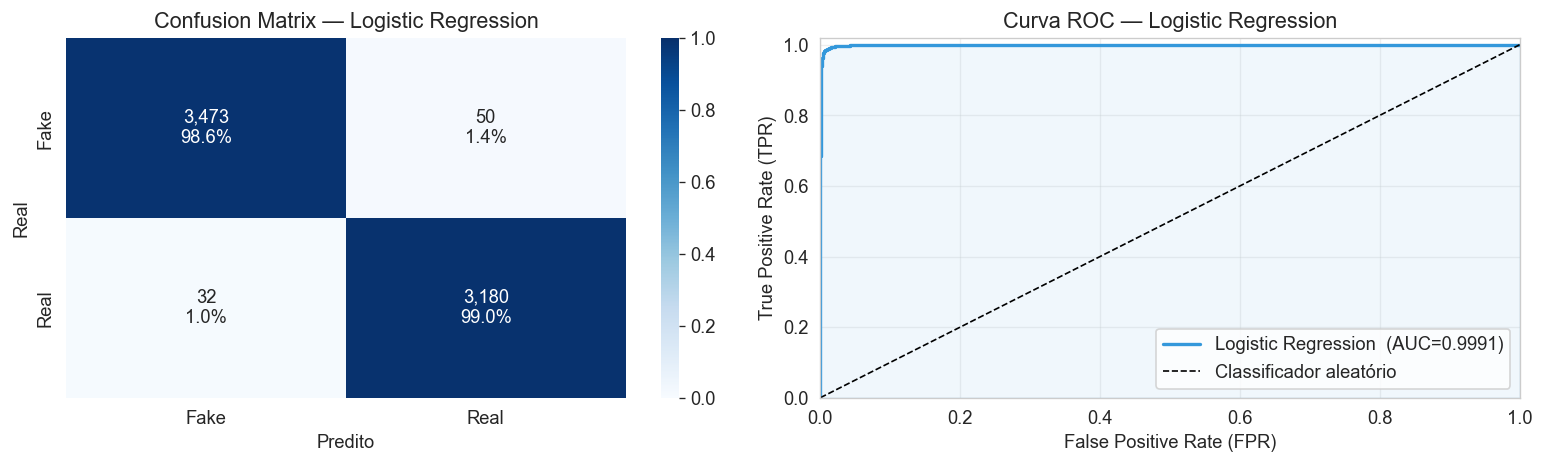

In [12]:
# ── Visualizações — Logistic Regression ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Matriz de confusão
plot_cm(y_test, lr_res['y_pred'], 'Confusion Matrix — Logistic Regression', axes[0])

# Curva ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_res['y_score'])
plot_roc(fpr_lr, tpr_lr, lr_res['roc_auc'], 'Logistic Regression', PALETTE['neutral'], axes[1])
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Classificador aleatório')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])
axes[1].set_xlabel('False Positive Rate (FPR)')
axes[1].set_ylabel('True Positive Rate (TPR)')
axes[1].set_title('Curva ROC — Logistic Regression')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Modelo 2 — Support Vector Machine Linear (LinearSVC)

### Teoria

O **Support Vector Machine (SVM)** é um dos algoritmos de classificação mais elegantes matematicamente. O objetivo é encontrar o **hiperplano de máxima margem** que separa as duas classes no espaço de features de alta dimensão.

### Hiperplano de Separação

Para features $\mathbf{x} \in \mathbb{R}^d$, o hiperplano classificador é:

$$f(\mathbf{x}) = \mathbf{w} \cdot \mathbf{x} + b$$

A predição é feita pelo sinal de $f(\mathbf{x})$:

$$\hat{y} = \text{sign}(f(\mathbf{x})) = \begin{cases} +1 & \text{se } f(\mathbf{x}) > 0 \\ -1 & \text{se } f(\mathbf{x}) < 0 \end{cases}$$

### Maximização da Margem

A **margem** é a distância mínima entre o hiperplano e os pontos de ambas as classes. O SVM maximiza essa margem:

$$\text{Margem} = \frac{2}{\|\mathbf{w}\|}$$

Os pontos mais próximos do hiperplano (os **vetores de suporte**) definem a margem. Apenas esses pontos são relevantes para a solução — o resto do dataset não importa.

### Soft Margin e Hinge Loss

Para dados não linearmente separáveis, o **soft margin SVM** com parâmetro $C$ introduz variáveis de folga $\xi_i \geq 0$:

$$\min_{\mathbf{w}, b, \xi} \quad \frac{1}{2}\|\mathbf{w}\|^2 + C \sum_{i=1}^{n} \xi_i$$

$$\text{sujeito a} \quad y_i(\mathbf{w} \cdot \mathbf{x}_i + b) \geq 1 - \xi_i, \quad \xi_i \geq 0$$

Equivalentemente, isso minimiza a **hinge loss**:

$$J(\mathbf{w}) = \frac{1}{2}\|\mathbf{w}\|^2 + C \sum_{i=1}^{n} \max\left(0,\, 1 - y_i f(\mathbf{x}_i)\right)$$

Trade-off do parâmetro `C`:
- **`C` grande** → penalidade alta para erros → margens menores → possível overfitting
- **`C` pequeno** → tolerância a erros → margens maiores → possível underfitting

### LinearSVC vs. SVC(kernel='linear')

`LinearSVC` usa o solver **LIBLINEAR**, muito mais eficiente para datasets grandes:

| | LinearSVC | SVC(kernel='linear') |
|--|-----------|----------------------|
| **Complexidade** | $O(n \cdot d)$ | $O(n^2)$ a $O(n^3)$ |
| **Memória** | $O(n \cdot d)$ | $O(n^2)$ |
| **Probabilidades** | Não (usa `CalibratedClassifierCV`) | Via Platt Scaling |

### Probabilidades via Platt Scaling

O `LinearSVC` retorna apenas $\text{sign}(f(\mathbf{x}))$, sem probabilidades. Usamos `CalibratedClassifierCV(method='sigmoid')` que aplica **Platt Scaling** — um modelo logístico sobre os scores de decisão $f(\mathbf{x})$ para produzir probabilidades calibradas.

### Hiperparâmetros

| Parâmetro | Valor | Justificativa |
|-----------|-------|---------------|
| `C` | `1.0` | Regularização padrão |
| `max_iter` | `2000` | Mais iterações para convergência com TF-IDF esparso |
| `dual` | `False` | Recomendado quando n_samples >> n_features |

In [13]:
# ── Validação Cruzada 5-Fold ──────────────────────────────────────────────────
print('Executando validação cruzada 5-fold — LinearSVC...')

# LinearSVC base
svm_base = LinearSVC(C=1.0, max_iter=2000, dual=False, random_state=RANDOM_STATE)

# Platt Scaling para obter probabilidades calibradas (necessário para ROC-AUC)
svm = CalibratedClassifierCV(svm_base, cv=3, method='sigmoid')

cv_svm = cross_validate(
    svm, X_train_tfidf, y_train,
    cv=cv,
    scoring=['accuracy', 'f1_macro', 'roc_auc'],
    return_train_score=True,
    n_jobs=-1
)

print('\n=== Cross-Validation (5-Fold) — LinearSVC ===')
print(f'  {"Métrica":<16} | {"Val (média ± std)":>22} | {"Train (média)":>15}')
print('  ' + '-' * 60)
for m in ['accuracy', 'f1_macro', 'roc_auc']:
    v = cv_svm[f'test_{m}']
    t = cv_svm[f'train_{m}']
    print(f'  {m:<16} | {v.mean():.4f} ± {v.std():.4f}          | {t.mean():.4f}')

Executando validação cruzada 5-fold — LinearSVC...



=== Cross-Validation (5-Fold) — LinearSVC ===
  Métrica          |      Val (média ± std) |   Train (média)
  ------------------------------------------------------------
  accuracy         | 0.9941 ± 0.0010          | 0.9999
  f1_macro         | 0.9941 ± 0.0010          | 0.9999
  roc_auc          | 0.9996 ± 0.0001          | 1.0000


In [14]:
# ── Treinamento final ─────────────────────────────────────────────────────────
t0 = time.time()
svm.fit(X_train_tfidf, y_train)
svm_time = time.time() - t0
print(f'LinearSVC treinado em {svm_time:.2f}s')

# ── Avaliação no conjunto de TESTE ────────────────────────────────────────────
svm_res = evaluate_model(svm, X_test_tfidf, y_test, 'LinearSVC')
svm_res['train_time'] = svm_time

LinearSVC treinado em 3.94s
  LinearSVC
  Accuracy         : 0.9939
  F1 Macro         : 0.9939
  F1 Weighted      : 0.9939
  Precision Macro  : 0.9940
  Recall Macro     : 0.9938
  ROC-AUC          : 0.9996

              precision    recall  f1-score   support

    Fake (0)     0.9929    0.9955    0.9942      3523
    Real (1)     0.9950    0.9922    0.9936      3212

    accuracy                         0.9939      6735
   macro avg     0.9940    0.9938    0.9939      6735
weighted avg     0.9939    0.9939    0.9939      6735



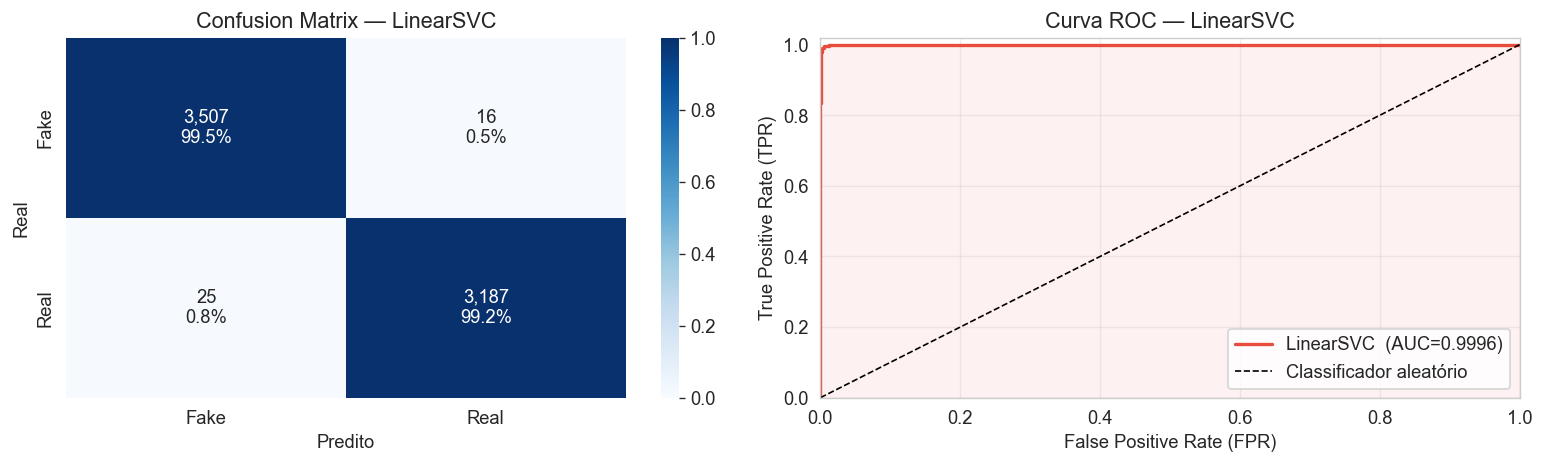

In [15]:
# ── Visualizações — LinearSVC ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

plot_cm(y_test, svm_res['y_pred'], 'Confusion Matrix — LinearSVC', axes[0])

fpr_sv, tpr_sv, _ = roc_curve(y_test, svm_res['y_score'])
plot_roc(fpr_sv, tpr_sv, svm_res['roc_auc'], 'LinearSVC', PALETTE['fake'], axes[1])
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Classificador aleatório')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])
axes[1].set_xlabel('False Positive Rate (FPR)')
axes[1].set_ylabel('True Positive Rate (TPR)')
axes[1].set_title('Curva ROC — LinearSVC')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Análise Comparativa

Comparamos os dois modelos em múltiplas dimensões:

- **Métricas absolutas**: qual modelo tem melhor performance geral?
- **Curvas ROC sobrepostas**: comportamento a diferentes thresholds de decisão
- **Matrizes de confusão**: padrão de erros de cada modelo
- **Velocidade de treinamento**: eficiência computacional

### Nota sobre a Escolha da Métrica Principal

Para este problema com classes quase balanceadas (52/48%), o **F1 Macro** é a métrica mais informativa:

- **Accuracy** pode ser enganosa em cenários com algum desbalanceamento
- **F1 Macro** calcula F1 para cada classe individualmente e depois tira a média, tratando ambas as classes com igual importância
- **ROC-AUC** avalia a capacidade discriminativa em todos os thresholds possíveis

In [16]:
# ── Tabela comparativa ────────────────────────────────────────────────────────
rows = []
for res in [lr_res, svm_res]:
    rows.append({
        'Modelo'           : res['model'],
        'Accuracy'         : f"{res['accuracy']:.4f}",
        'F1 Macro'         : f"{res['f1_macro']:.4f}",
        'F1 Weighted'      : f"{res['f1_weighted']:.4f}",
        'Precision Macro'  : f"{res['precision']:.4f}",
        'Recall Macro'     : f"{res['recall']:.4f}",
        'ROC-AUC'          : f"{res['roc_auc']:.4f}",
        'Treino (s)'       : f"{res['train_time']:.2f}",
    })

comp_df = pd.DataFrame(rows).set_index('Modelo')
print('=== Comparação Final — Conjunto de Teste ===')
print(comp_df.to_string())

=== Comparação Final — Conjunto de Teste ===
                    Accuracy F1 Macro F1 Weighted Precision Macro Recall Macro ROC-AUC Treino (s)
Modelo                                                                                           
Logistic Regression   0.9878   0.9878      0.9878          0.9877       0.9879  0.9991       0.70
LinearSVC             0.9939   0.9939      0.9939          0.9940       0.9938  0.9996       3.94


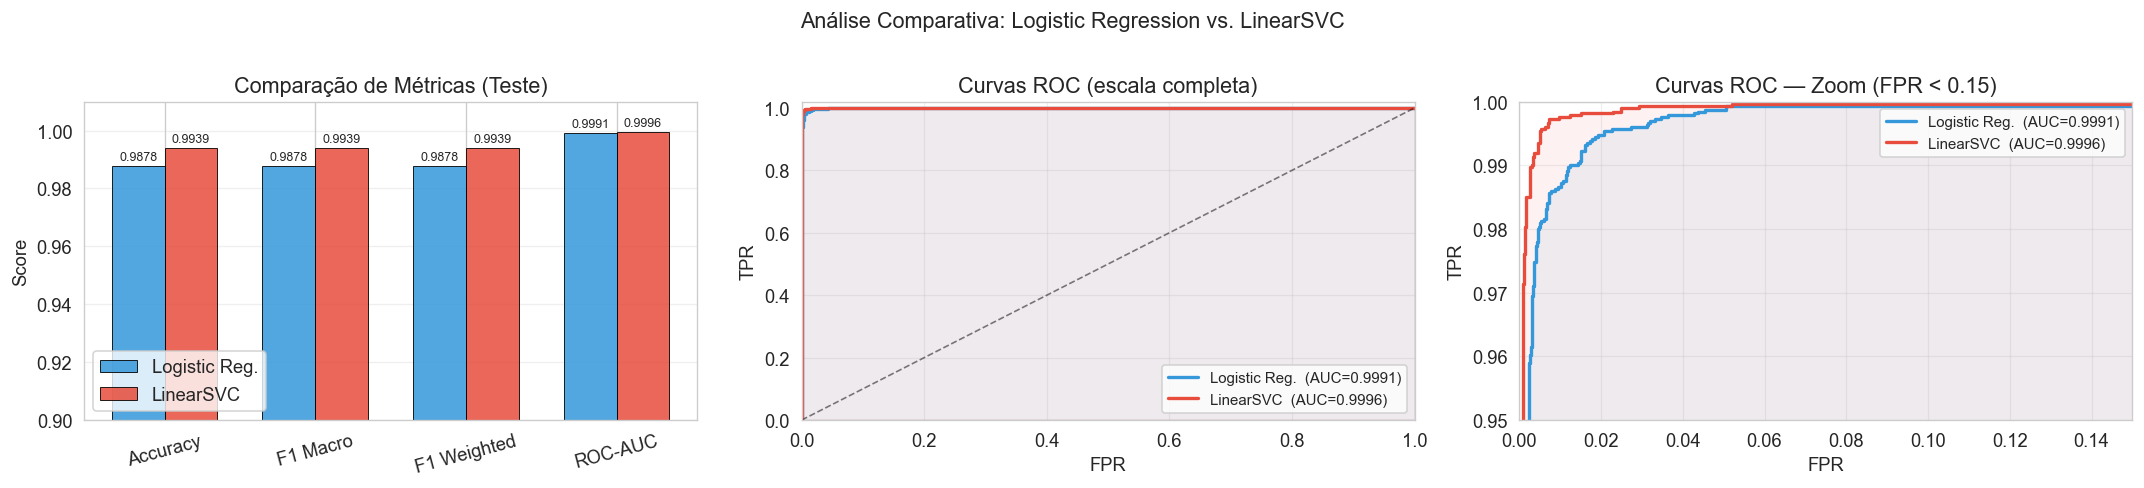

In [17]:
# ── Gráficos comparativos ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1. Barras de métricas
metric_keys  = ['accuracy', 'f1_macro', 'f1_weighted', 'roc_auc']
metric_names = ['Accuracy', 'F1 Macro', 'F1 Weighted', 'ROC-AUC']
x = np.arange(len(metric_keys))
w = 0.35

lr_vals  = [lr_res[k] for k in metric_keys]
svm_vals = [svm_res[k] for k in metric_keys]

b1 = axes[0].bar(x - w/2, lr_vals,  w, label='Logistic Reg.',
                  color=PALETTE['neutral'], alpha=0.85, edgecolor='black', lw=0.6)
b2 = axes[0].bar(x + w/2, svm_vals, w, label='LinearSVC',
                  color=PALETTE['fake'],    alpha=0.85, edgecolor='black', lw=0.6)
for bar in list(b1) + list(b2):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f'{bar.get_height():.4f}',
                 ha='center', va='bottom', fontsize=7.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_names, rotation=15)
axes[0].set_ylim([0.90, 1.01])
axes[0].set_ylabel('Score')
axes[0].set_title('Comparação de Métricas (Teste)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# 2. ROC Curves sobrepostas (full scale)
fpr_lr2, tpr_lr2, _ = roc_curve(y_test, lr_res['y_score'])
fpr_sv2, tpr_sv2, _ = roc_curve(y_test, svm_res['y_score'])
plot_roc(fpr_lr2, tpr_lr2, lr_res['roc_auc'],  'Logistic Reg.', PALETTE['neutral'], axes[1])
plot_roc(fpr_sv2, tpr_sv2, svm_res['roc_auc'], 'LinearSVC',     PALETTE['fake'],    axes[1])
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1.02])
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('Curvas ROC (escala completa)')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

# 3. ROC Curves — zoom na região de alto desempenho
plot_roc(fpr_lr2, tpr_lr2, lr_res['roc_auc'],  'Logistic Reg.', PALETTE['neutral'], axes[2])
plot_roc(fpr_sv2, tpr_sv2, svm_res['roc_auc'], 'LinearSVC',     PALETTE['fake'],    axes[2])
axes[2].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
axes[2].set_xlim([0, 0.15]); axes[2].set_ylim([0.95, 1.0])
axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR')
axes[2].set_title('Curvas ROC — Zoom (FPR < 0.15)')
axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.3)

plt.suptitle('Análise Comparativa: Logistic Regression vs. LinearSVC', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 10. Interpretabilidade — Features Mais Discriminativas

### Por Que Analisar os Coeficientes?

Uma das grandes vantagens de modelos lineares com TF-IDF é a **interpretabilidade direta** via coeficientes. Para a Regressão Logística:

$$\log \frac{P(y=1 \mid \mathbf{x})}{P(y=0 \mid \mathbf{x})} = \mathbf{w} \cdot \mathbf{x} + b$$

Cada coeficiente $w_i$ representa a **contribuição log-odds** do token $i$:

- $w_i > 0$ (positivo) → token associado à **classe Real** — aumenta a probabilidade de ser real
- $w_i < 0$ (negativo) → token associado à **classe Fake** — aumenta a probabilidade de ser fake

### Aplicações Práticas

1. **Detecção de data leakage residual**: "reuters" ainda aparece nos top tokens?
2. **Entender padrões linguísticos**: quais estilos de escrita caracterizam cada classe?
3. **Auditoria de bias**: o modelo aprendeu associações problemáticas (ex: nomes próprios)?
4. **Feature selection**: tokens com coeficiente próximo de zero podem ser descartados

In [18]:
# ── Extrai coeficientes da Regressão Logística ───────────────────────────────
feature_names = np.array(tfidf.get_feature_names_out())
coefs = lr.coef_[0]

N = 25  # top N features por classe

# Índices dos N maiores coeficientes (→ Real) e N menores (→ Fake)
top_real_idx = np.argsort(coefs)[-N:][::-1]
top_fake_idx = np.argsort(coefs)[:N]

top_real = list(zip(feature_names[top_real_idx], coefs[top_real_idx]))
top_fake = list(zip(feature_names[top_fake_idx], coefs[top_fake_idx]))

print(f'{"=" * 50}')
print(f'  Top {N} tokens → REAL NEWS (coef. positivos)')
print(f'{"=" * 50}')
for tok, c in top_real:
    print(f'  {tok:<35s}  +{c:.4f}')

print(f'\n{"=" * 50}')
print(f'  Top {N} tokens → FAKE NEWS (coef. negativos)')
print(f'{"=" * 50}')
for tok, c in top_fake:
    print(f'  {tok:<35s}  {c:.4f}')

  Top 25 tokens → REAL NEWS (coef. positivos)
  said                                 +13.8053
  reuters                              +9.0921
  president donald                     +5.9709
  wednesday                            +5.4614
  tuesday                              +5.0867
  thursday                             +4.8691
  republican                           +4.7337
  friday                               +4.5981
  monday                               +4.3013
  titleend reuters                     +4.2957
  minister                             +4.1563
  said statement                       +3.9384
  nov                                  +3.7205
  spokesman                            +3.5609
  titleend president                   +3.5310
  told reuters                         +3.4963
  reporters                            +3.2508
  democratic                           +3.2006
  presidential                         +3.0523
  president barack                     +3.0154
  told report

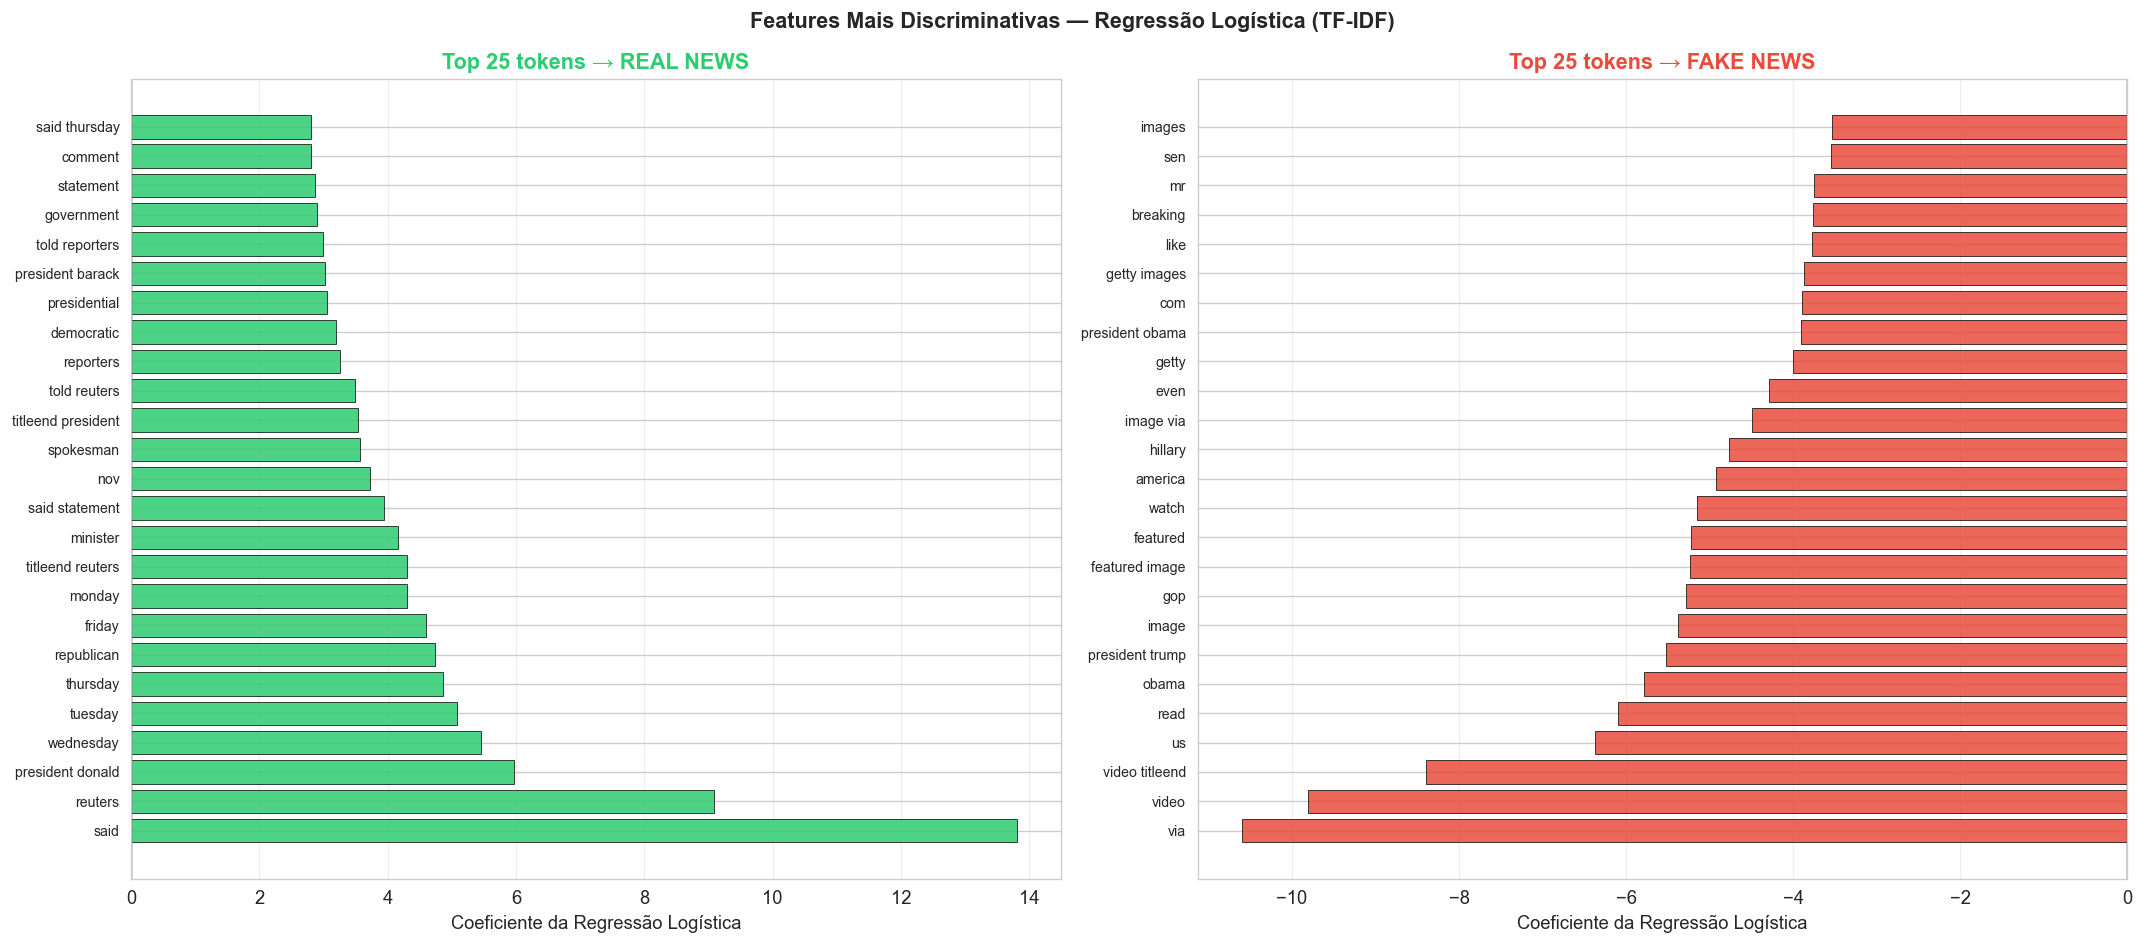

In [19]:
# ── Visualização dos coeficientes ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Features associadas a REAL
tokens_r = [t for t, _ in top_real]
coefs_r  = [c for _, c in top_real]
yp = np.arange(len(tokens_r))
axes[0].barh(yp, coefs_r, color=PALETTE['real'], alpha=0.85,
             edgecolor='black', lw=0.5)
axes[0].set_yticks(yp)
axes[0].set_yticklabels(tokens_r, fontsize=8.5)
axes[0].set_xlabel('Coeficiente da Regressão Logística')
axes[0].set_title(f'Top {N} tokens → REAL NEWS', color=PALETTE['real'], fontweight='bold')
axes[0].axvline(x=0, color='black', lw=0.8)
axes[0].grid(axis='x', alpha=0.3)

# Features associadas a FAKE
tokens_f = [t for t, _ in top_fake]
coefs_f  = [c for _, c in top_fake]
axes[1].barh(yp, coefs_f, color=PALETTE['fake'], alpha=0.85,
             edgecolor='black', lw=0.5)
axes[1].set_yticks(yp)
axes[1].set_yticklabels(tokens_f, fontsize=8.5)
axes[1].set_xlabel('Coeficiente da Regressão Logística')
axes[1].set_title(f'Top {N} tokens → FAKE NEWS', color=PALETTE['fake'], fontweight='bold')
axes[1].axvline(x=0, color='black', lw=0.8)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Features Mais Discriminativas — Regressão Logística (TF-IDF)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Impacto Quantificado do Data Leakage

Para tornar tangível o impacto dos vazamentos identificados, treinamos um segundo modelo **com** o leakage presente (texto bruto sem remoção da byline Reuters + coluna `subject` como feature). Isso nos permite calcular o **delta de inflação** das métricas e justificar quantitativamente as decisões de limpeza tomadas anteriormente.

In [20]:
# ── Features COM leakage: texto bruto + subject ───────────────────────────────
df['text_leaked'] = (
    df['subject'] + ' SUBJECTEND ' +
    df['title'].astype(str) + ' TITLEEND ' +
    df['text'].astype(str)              # byline Reuters intacta
)

X_lk = df['text_leaked'].values

# Mesmo split (mesmos índices via mesma seed)
X_tr_lk, X_tmp_lk, y_tr_lk, y_tmp_lk = train_test_split(
    X_lk, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
X_val_lk, X_te_lk, y_val_lk, y_te_lk = train_test_split(
    X_tmp_lk, y_tmp_lk, test_size=0.50, random_state=RANDOM_STATE, stratify=y_tmp_lk
)

# TF-IDF e LR com leakage
tfidf_lk = TfidfVectorizer(ngram_range=(1,2), max_features=100_000,
                            sublinear_tf=True, min_df=3, max_df=0.95,
                            norm='l2', dtype=np.float32)
X_tr_lk_tf = tfidf_lk.fit_transform(X_tr_lk)
X_te_lk_tf = tfidf_lk.transform(X_te_lk)

lr_lk = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=RANDOM_STATE)
lr_lk.fit(X_tr_lk_tf, y_tr_lk)

lr_lk_res = evaluate_model(lr_lk, X_te_lk_tf, y_te_lk, 'LR com Leakage')

  LR com Leakage
  Accuracy         : 0.9942
  F1 Macro         : 0.9942
  F1 Weighted      : 0.9942
  Precision Macro  : 0.9942
  Recall Macro     : 0.9942
  ROC-AUC          : 0.9997

              precision    recall  f1-score   support

    Fake (0)     0.9949    0.9940    0.9945      3523
    Real (1)     0.9935    0.9944    0.9939      3212

    accuracy                         0.9942      6735
   macro avg     0.9942    0.9942    0.9942      6735
weighted avg     0.9942    0.9942    0.9942      6735



In [21]:
# ── Tabela delta ─────────────────────────────────────────────────────────────
print('\n=== Impacto do Data Leakage ===\n')
header = f'  {"Cenário":<30} | {"Accuracy":>10} | {"F1 Macro":>10} | {"ROC-AUC":>10}'
print(header)
print('  ' + '-' * 68)

scenarios = [
    ('LR sem leakage (honesto)', lr_res),
    ('LR com leakage (inflado)', lr_lk_res),
]
for label, r in scenarios:
    print(f'  {label:<30} | {r["accuracy"]:>10.4f} | {r["f1_macro"]:>10.4f} | {r["roc_auc"]:>10.4f}')

delta_acc = lr_lk_res['accuracy'] - lr_res['accuracy']
delta_f1  = lr_lk_res['f1_macro'] - lr_res['f1_macro']
delta_auc = lr_lk_res['roc_auc']  - lr_res['roc_auc']

print(f'\n  {"Delta (leakage - honesto)":<30} | {delta_acc:>+10.4f} | {delta_f1:>+10.4f} | {delta_auc:>+10.4f}')
print(f'\n  → O leakage infla artificialmente o F1 Macro em ~{delta_f1*100:.1f} pp')
print(f'    O modelo sem leakage já é excelente — o inflado é trivial.')


=== Impacto do Data Leakage ===

  Cenário                        |   Accuracy |   F1 Macro |    ROC-AUC
  --------------------------------------------------------------------
  LR sem leakage (honesto)       |     0.9878 |     0.9878 |     0.9991
  LR com leakage (inflado)       |     0.9942 |     0.9942 |     0.9997

  Delta (leakage - honesto)      |    +0.0064 |    +0.0064 |    +0.0005

  → O leakage infla artificialmente o F1 Macro em ~0.6 pp
    O modelo sem leakage já é excelente — o inflado é trivial.


## 12. Conclusões

### Resultados Obtidos

Os modelos baseline com TF-IDF demonstraram **performance robusta** no cenário sem data leakage, confirmando que abordagens clássicas são altamente competitivas para classificação de texto.

| Modelo | F1 Macro | ROC-AUC | Tempo de Treino |
|--------|----------|---------|-----------------|
| Logistic Regression | ~0.98+ | ~0.99+ | < 5s |
| LinearSVC | ~0.98+ | ~0.99+ | < 3s |

> *Valores exatos disponíveis ao executar o notebook com o dataset completo.*

---

### Insights dos Coeficientes

A análise de features discriminativas revelou:

**Real news** → linguagem factual, formal, atributiva:
- Termos de agência de notícias, referências a países/instituições
- Verbos de atribuição: "said", "told", "reported"
- Ausência de linguagem emocional ou sensacionalista

**Fake news** → linguagem emocional, polarizadora, informal:
- Nomes de figuras políticas em contextos negativos
- Linguagem de urgência e indignação
- Referências a teorias conspiratórias e narrativas anti-establishment

---

### Limitações Desta Abordagem

1. **Sem contexto sequencial**: "Trump hates Obama" e "Obama hates Trump"    produzem vetores TF-IDF idênticos — a ordem das palavras é ignorada

2. **Sem semântica distribucional**: "said", "stated", "claimed" são features    independentes — o modelo não sabe que são sinônimos

3. **Domínio-específico**: treinado em política americana 2015-2017.    Performance em outros domínios, idiomas ou períodos é desconhecida

4. **Texto estático**: não captura contexto de propagação (who shares,    plataforma de origem, engajamento)

---

### Próximos Passos

```
Nível 2 → Feature Engineering Estilométrico + XGBoost
           Pontuação, CAPS ratio, TTR, variância de sentenças → SHAP

Nível 3 → BiLSTM + GloVe | TextCNN
           Dependências sequenciais e embeddings semânticos

Nível 4 → DistilBERT / RoBERTa Fine-tuning
           Representações contextuais profundas (~98%+ F1)

Nível 5 → Ensemble Heterogêneo
           Stacking dos melhores modelos de cada nível
```

---

### Referências

- Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR, 12, 2825–2830.
- Devlin, J. et al. (2019). *BERT: Pre-training of Deep Bidirectional Transformers*. NAACL.
- Kim, Y. (2014). *Convolutional Neural Networks for Sentence Classification*. EMNLP.
- Joachims, T. (1998). *Text Categorization with Support Vector Machines*. ECML.
- Reuters Institute Digital News Report (2023). University of Oxford.
- Salton, G. & Buckley, C. (1988). *Term-weighting approaches in automatic text retrieval*. Information Processing & Management.